# 06 — Tweak-Order Plate-Solving Comparison

**Purpose:** Request the same astrometry.net plate solve at SIP tweak orders 2–5 and
compare the returned WCS headers side-by-side.

This is a *baseline generation* notebook, not a full diagnostic. The goal is:
- Confirm astrometry.net accepts `tweak_order` and returns correspondingly higher SIP.
- Cache one `result.pkl` per order in `working/platesolve_tweak_order_<N>/`.
- Produce a 2×2 overlay figure and a summary CSV for later comparison.

Full regional/angle analysis (left vs right consistency, angle-impact table) is
deferred to later diagnostic notebooks.

In [1]:
import sys, warnings, pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter
from astropy.io import fits as afits
from astropy.wcs import WCS
from astropy.table import Table

ROOT      = Path('..').resolve()
FITS_PATH = sorted((ROOT / 'data').glob('*.fit'))[0]
sys.path.insert(0, str(ROOT))

from extractor.platesolve import platesolve, has_sip, wcs_summary

TWEAK_ORDERS = [2, 3, 4, 5]
COMP_DIR = ROOT / 'working' / 'tweak_order_comparison'
COMP_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#111', 'axes.facecolor': '#111',
    'text.color': 'white', 'axes.labelcolor': 'white',
    'xtick.color': '#ccc',  'ytick.color': '#ccc',
    'axes.edgecolor': '#555', 'axes.titlecolor': 'white',
    'legend.facecolor': '#1e1e1e', 'legend.edgecolor': '#555',
    'grid.color': '#333', 'grid.alpha': 0.4,
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'savefig.facecolor': '#111', 'savefig.dpi': 150,
})

with afits.open(FITS_PATH) as hdul:
    image = hdul[0].data.astype(float)
h, w = image.shape

# Display stretch (shared across all panels)
_bg   = gaussian_filter(image.astype(np.float32), sigma=50)
_proc = np.clip(image.astype(np.float32) - _bg, 0, None)
_lo, _hi = np.percentile(_proc[np.isfinite(_proc)], [0.5, 99.5])
disp = np.arcsinh(np.clip(_proc, _lo, _hi))
_vlo, _vhi = float(np.arcsinh(_lo)), float(np.arcsinh(_hi))

print(f'Image    : {FITS_PATH.name}  ({w} x {h} px)')
print(f'Orders   : {TWEAK_ORDERS}')
print(f'Comp dir : {COMP_DIR}')

Image    : fuji6_asi178_100_15s.fit  (3096 x 2080 px)
Orders   : [2, 3, 4, 5]
Comp dir : C:\Users\bassd\Research\Spectra Angle\spectrangle\working\tweak_order_comparison


## Run (or load) one solve per tweak order

Results are cached in `working/platesolve_tweak_order_<N>/result.pkl`.
Re-running this cell after the first successful run will load from cache.

In [2]:
results = {}

for order in TWEAK_ORDERS:
    work_dir   = ROOT / 'working' / f'platesolve_tweak_order_{order}'
    cache_path = work_dir / 'result.pkl'
    work_dir.mkdir(parents=True, exist_ok=True)

    print(f'\n=== tweak_order={order} ===')
    result = platesolve(
        FITS_PATH,
        use_source_list=True,
        max_sources=300,
        mask_spectra=True,
        write=False,
        fetch_products=True,
        save_products_dir=work_dir,
        tweak_order=order,
        cache=cache_path,
        verbose=True,
    )
    results[order] = result
    if result is None:
        print(f'  FAILED for tweak_order={order}')
    else:
        a_ord = result.header.get('A_ORDER', 'n/a')
        b_ord = result.header.get('B_ORDER', 'n/a')
        print(f'  Returned A_ORDER={a_ord}  B_ORDER={b_ord}')

print('\nAll solves complete.')


=== tweak_order=2 ===
Logged in to nova.astrometry.net
Detected 255 sources (mask_spectra=True).
Source list uploaded (submission 14950662)
Waiting for job assignment.. job 15786606
Solving.. solved!
WCS header fetched.
Fetching astrometry.net products:
  corr: HTTP 200, Content-Type=application/fits, url=https://nova.astrometry.net/corr_file/15786606
  corr: 14400 bytes, first 16: b'SIMPLE  =       '
  corr: HDU0=PrimaryHDU, HDU1=BinTableHDU
  corr: 48 rows | cols: ['field_x', 'field_y', 'field_ra', 'field_dec', 'index_x', 'index_y', 'index_ra', 'index_dec', 'index_id', 'field_id', 'match_weight', 'MAG_BT', 'MAG_VT', 'MAG_HP', 'MAG']
  axy: HTTP 200, Content-Type=application/fits, url=https://nova.astrometry.net/axy_file/15786606
  axy: 11520 bytes, first 16: b'SIMPLE  =       '
  axy: HDU0=PrimaryHDU, HDU1=BinTableHDU
  axy: 255 rows | cols: ['X', 'Y']
  rdls: HTTP 200, Content-Type=application/fits, url=https://nova.astrometry.net/rdls_file/15786606
  rdls: 69120 bytes, first 16: b

## Per-order summary

In [3]:
def _gcol(tbl, *names):
    if tbl is None:
        return np.array([])
    lm = {c.strip().lower(): c for c in tbl.colnames}
    for n in names:
        k = lm.get(n.strip().lower())
        if k is not None:
            return np.asarray(tbl[k], dtype=float)
    return np.array([])

def _north_angle(wcs_obj, x, y, step_deg=0.05):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        ra0, dec0 = wcs_obj.pixel_to_world_values(x, y)
        pxn, pyn  = wcs_obj.world_to_pixel_values(ra0, dec0 + step_deg)
    return float(np.degrees(np.arctan2(pyn - y, pxn - x)))

rows = []
cx, cy = w / 2.0, h / 2.0

print(f"{'Order':>6}  {'Status':>8}  {'A_ORD':>6}  {'B_ORD':>6}  "
      f"{'RA':>12}  {'Dec':>11}  {'NorthAng':>10}  "
      f"{'Scale"':>8}  {'axy':>5}  {'rdls':>5}  {'img_rd':>7}  {'corr':>5}")
print('-' * 110)

for order in TWEAK_ORDERS:
    result = results.get(order)
    work_dir = ROOT / 'working' / f'platesolve_tweak_order_{order}'

    if result is None:
        rows.append({'tweak_order': order, 'status': 'FAILED',
                     'returned_sip_order': None, 'center_ra': None,
                     'center_dec': None, 'center_north_angle_deg': None,
                     'plate_scale_arcsec_px': None,
                     'n_axy': 0, 'n_rdls': 0, 'n_image_rd': 0, 'n_corr': 0,
                     'working_dir': str(work_dir)})
        print(f"{order:>6}  {'FAILED':>8}")
        continue

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        wcs = WCS(result.header)
        ra0, dec0 = wcs.pixel_to_world_values(cx, cy)
        ra1, dec1 = wcs.pixel_to_world_values(cx + 1, cy)

    cosd      = np.cos(np.radians(dec0))
    scale_as  = np.hypot((ra1 - ra0) * cosd, dec1 - dec0) * 3600
    north     = _north_angle(wcs, cx, cy)

    a_ord = result.header.get('A_ORDER', None)
    b_ord = result.header.get('B_ORDER', None)
    sip_ord = max(a_ord or 0, b_ord or 0) if (a_ord or b_ord) else None

    n_axy    = len(result.axy_table)          if result.axy_table    is not None else 0
    n_rdls   = len(result.rdls_table)         if result.rdls_table   is not None else 0
    n_imrd   = len(result.image_radec_table)  if result.image_radec_table is not None else 0
    n_corr   = len(result.corr_table)         if result.corr_table   is not None else 0

    rows.append({
        'tweak_order':           order,
        'status':                result.status,
        'returned_sip_order':    sip_ord,
        'center_ra':             float(ra0),
        'center_dec':            float(dec0),
        'center_north_angle_deg': float(north),
        'plate_scale_arcsec_px': float(scale_as),
        'n_axy':                 n_axy,
        'n_rdls':                n_rdls,
        'n_image_rd':            n_imrd,
        'n_corr':                n_corr,
        'working_dir':           str(work_dir),
    })

    print(f"{order:>6}  {result.status:>8}  {str(a_ord):>6}  {str(b_ord):>6}  "
          f"{float(ra0):>12.5f}  {float(dec0):>11.5f}  {float(north):>10.3f}  "
          f"{float(scale_as):>7.1f}"  f'"  {n_axy:>5}  {n_rdls:>5}  {n_imrd:>7}  {n_corr:>5}')

summary_df = pd.DataFrame(rows)
csv_path   = COMP_DIR / 'tweak_order_summary.csv'
summary_df.to_csv(csv_path, index=False)
print(f'\nSaved {csv_path}')

 Order    Status   A_ORD   B_ORD            RA          Dec    NorthAng    Scale"    axy   rdls   img_rd   corr
--------------------------------------------------------------------------------------------------------------
     2   success       2       2     113.40377     30.39182    -106.838     80.0"    255    179      255     48
     3   success       3       3     113.39217     30.38693    -106.800     80.2"    255    179      255     51
     4   success       4       4     113.41296     30.40359    -107.121     80.9"    255    741      255    132
     5   success       5       5     113.41498     30.41246    -107.010     80.5"    255    179      255     86

Saved C:\Users\bassd\Research\Spectra Angle\spectrangle\working\tweak_order_comparison\tweak_order_summary.csv


## 2×2 overlay figure

One panel per tweak order: submitted sources (white) + rdls reference stars
projected through that solve's WCS (cyan). Title shows requested vs returned SIP order.

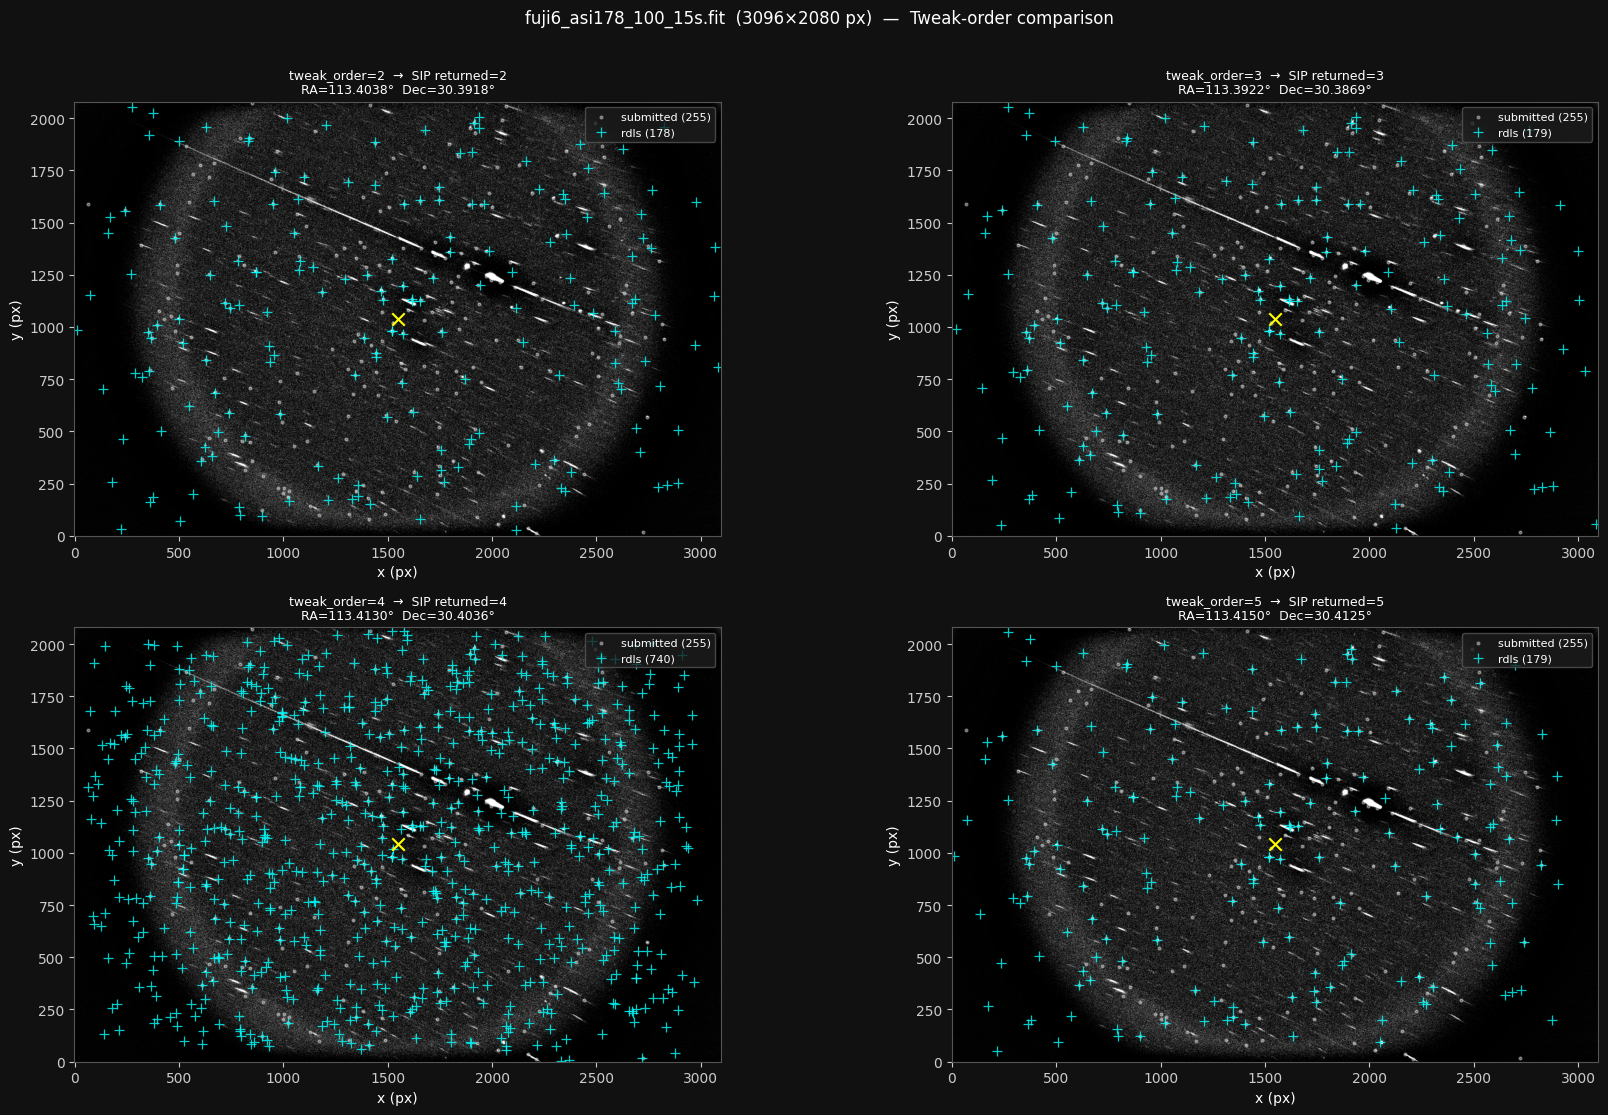

Saved C:\Users\bassd\Research\Spectra Angle\spectrangle\working\tweak_order_comparison\tweak_order_overlay_grid.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(18, 11))

for idx, order in enumerate(TWEAK_ORDERS):
    ax     = axes[idx // 2][idx % 2]
    result = results.get(order)
    row    = next((r for r in rows if r['tweak_order'] == order), {})

    ax.imshow(disp, origin='lower', cmap='gray', vmin=_vlo, vmax=_vhi, aspect='equal')

    if result is None:
        ax.set_title(f'tweak_order={order}  FAILED', fontsize=10)
        ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
        continue

    # Submitted sources
    ax.scatter(result.detected_x, result.detected_y,
               s=4, c='white', alpha=0.35,
               label=f'submitted ({len(result.detected_x)})')

    # RDLS projected through this solve's WCS
    rdls_tbl = result.rdls_table
    if rdls_tbl is not None:
        rdls_ra  = _gcol(rdls_tbl, 'ra')
        rdls_dec = _gcol(rdls_tbl, 'dec')
        if len(rdls_ra) > 0:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                _wcs = WCS(result.header)
                rdls_px = _wcs.all_world2pix(
                    np.column_stack([rdls_ra, rdls_dec]), 0)
            _ib = ((rdls_px[:, 0] >= 0) & (rdls_px[:, 0] < w) &
                   (rdls_px[:, 1] >= 0) & (rdls_px[:, 1] < h))
            ax.scatter(rdls_px[_ib, 0], rdls_px[_ib, 1],
                       s=50, marker='+', c='cyan', linewidths=0.9, alpha=0.8,
                       label=f'rdls ({_ib.sum()})')

    # Image centre marker
    ax.scatter([cx], [cy], marker='x', c='yellow', s=80, linewidths=1.5, zorder=5)

    sip_ret = row.get('returned_sip_order', 'n/a')
    ra_c    = row.get('center_ra',  float('nan'))
    dec_c   = row.get('center_dec', float('nan'))
    ax.set_title(
        f'tweak_order={order}  →  SIP returned={sip_ret}\n'
        f'RA={ra_c:.4f}°  Dec={dec_c:.4f}°',
        fontsize=9)
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(-0.5, h - 0.5)

fig.suptitle(
    f'{FITS_PATH.name}  ({w}×{h} px)  —  Tweak-order comparison',
    fontsize=12, y=1.01)
fig.tight_layout()

grid_path = COMP_DIR / 'tweak_order_overlay_grid.png'
fig.savefig(grid_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {grid_path}')

## Individual overlays (one per tweak order)

In [5]:
for order in TWEAK_ORDERS:
    result   = results.get(order)
    work_dir = ROOT / 'working' / f'platesolve_tweak_order_{order}'
    row      = next((r for r in rows if r['tweak_order'] == order), {})

    fig2, ax2 = plt.subplots(figsize=(14, 8))
    ax2.imshow(disp, origin='lower', cmap='gray', vmin=_vlo, vmax=_vhi, aspect='equal')

    if result is not None:
        ax2.scatter(result.detected_x, result.detected_y,
                    s=5, c='white', alpha=0.35,
                    label=f'submitted ({len(result.detected_x)})')

        rdls_tbl = result.rdls_table
        if rdls_tbl is not None:
            rdls_ra  = _gcol(rdls_tbl, 'ra')
            rdls_dec = _gcol(rdls_tbl, 'dec')
            if len(rdls_ra) > 0:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore')
                    _wcs = WCS(result.header)
                    rdls_px = _wcs.all_world2pix(
                        np.column_stack([rdls_ra, rdls_dec]), 0)
                _ib = ((rdls_px[:, 0] >= 0) & (rdls_px[:, 0] < w) &
                       (rdls_px[:, 1] >= 0) & (rdls_px[:, 1] < h))
                ax2.scatter(rdls_px[_ib, 0], rdls_px[_ib, 1],
                            s=55, marker='+', c='cyan', linewidths=0.9, alpha=0.8,
                            label=f'rdls ({_ib.sum()})')

        ax2.scatter([cx], [cy], marker='x', c='yellow', s=100, linewidths=1.5, zorder=5)

        sip_ret = row.get('returned_sip_order', 'n/a')
        scale   = row.get('plate_scale_arcsec_px', float('nan'))
        ax2.set_title(
            f'tweak_order={order}  →  SIP returned={sip_ret}  |  '
            f'scale≈{scale:.0f}"/px  |  {FITS_PATH.name}',
            fontsize=11)
        ax2.legend(loc='upper right', fontsize=9)

    ax2.set_xlim(-0.5, w - 0.5); ax2.set_ylim(-0.5, h - 0.5)
    ax2.set_xlabel('x (px)'); ax2.set_ylabel('y (px)')

    fig2.tight_layout()
    out = work_dir / f'overlay_tweak{order}.png'
    fig2.savefig(out, dpi=150, bbox_inches='tight')
    plt.close(fig2)
    print(f'Saved {out.relative_to(ROOT)}')

Saved working\platesolve_tweak_order_2\overlay_tweak2.png
Saved working\platesolve_tweak_order_3\overlay_tweak3.png
Saved working\platesolve_tweak_order_4\overlay_tweak4.png
Saved working\platesolve_tweak_order_5\overlay_tweak5.png


## WCS header detail per order

In [6]:
for order in TWEAK_ORDERS:
    result = results.get(order)
    print(f'\n--- tweak_order={order} ---')
    if result is None:
        print('  FAILED')
        continue
    a_ord = result.header.get('A_ORDER', 'absent')
    b_ord = result.header.get('B_ORDER', 'absent')
    print(f'  A_ORDER={a_ord}  B_ORDER={b_ord}  SIP={has_sip(result.header)}')
    print(wcs_summary(result.header))


--- tweak_order=2 ---
  A_ORDER=2  B_ORDER=2  SIP=True
  CTYPE1  : RA---TAN-SIP
  CTYPE2  : DEC--TAN-SIP
  CRVAL1  : 120.61262
  CRVAL2  : 29.788056
  CRPIX1  : 1286.8585
  CRPIX2  : 1140.5638
  CD1_1   : -0.0218561
  CD1_2   : 0.00514579
  CD2_1   : -0.00525836
  CD2_2   : -0.0219369
  SIP     : yes (order 2)

--- tweak_order=3 ---
  A_ORDER=3  B_ORDER=3  SIP=True
  CTYPE1  : RA---TAN-SIP
  CTYPE2  : DEC--TAN-SIP
  CRVAL1  : 120.60845
  CRVAL2  : 29.781936
  CRPIX1  : 1286.8585
  CRPIX2  : 1140.5638
  CD1_1   : -0.0218305
  CD1_2   : 0.00520035
  CD2_1   : -0.00521273
  CD2_2   : -0.0218854
  SIP     : yes (order 3)

--- tweak_order=4 ---
  A_ORDER=4  B_ORDER=4  SIP=True
  CTYPE1  : RA---TAN-SIP
  CTYPE2  : DEC--TAN-SIP
  CRVAL1  : 115.3934
  CRVAL2  : 28.089818
  CRPIX1  : 1504.7078
  CRPIX2  : 1161.2143
  CD1_1   : -0.0216077
  CD1_2   : 0.00623475
  CD2_1   : -0.00616475
  CD2_2   : -0.0216062
  SIP     : yes (order 4)

--- tweak_order=5 ---
  A_ORDER=5  B_ORDER=5  SIP=True
  CTYP

## Summary table

In [7]:
print(summary_df.to_string(index=False))
print(f'\nSaved to {csv_path}')

 tweak_order  status  returned_sip_order  center_ra  center_dec  center_north_angle_deg  plate_scale_arcsec_px  n_axy  n_rdls  n_image_rd  n_corr                                                                        working_dir
           2 success                   2 113.403767   30.391818             -106.838497              80.012657    255     179         255      48 C:\Users\bassd\Research\Spectra Angle\spectrangle\working\platesolve_tweak_order_2
           3 success                   3 113.392174   30.386927             -106.800344              80.232132    255     179         255      51 C:\Users\bassd\Research\Spectra Angle\spectrangle\working\platesolve_tweak_order_3
           4 success                   4 113.412964   30.403594             -107.120803              80.878300    255     741         255     132 C:\Users\bassd\Research\Spectra Angle\spectrangle\working\platesolve_tweak_order_4
           5 success                   5 113.414981   30.412455             -107.009

## Interpretation

This notebook only checks whether astrometry.net accepts `tweak_order` and returns
correspondingly higher-order SIP. A successful solve and a higher `A_ORDER`/`B_ORDER`
in the returned header confirms the request was honored.

**Passing the solve test is not enough.** The real pass/fail criteria will be checked
in a follow-on diagnostic notebook:

- Do left/right/center regional sub-solves agree better for each tweak order?
- Do projected reference stars land nearer detected sources across the full detector?
- Does the centre north-angle stabilise (smaller spread across regional solves)?
- Does the angle-impact table shrink from degree-scale toward the ~0.1° target?

Higher order is not automatically better — it can overfit with sparse reference stars.
The current SIP=2 model appears insufficient for this ~70° field, but whether order
3/4/5 actually helps or just adds noise is an empirical question answered by the
regional consistency analysis.